In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [10]:
# ------------------------------
# 1. Konfigurasi
# ------------------------------
model_path = '../results_kfold/best_model_fold_3.h5'       # Ganti dengan path file .h5 Anda
test_dir = 'data_test'       # Ganti dengan path folder testing Anda
target_size = (224, 224)         # Sesuaikan dengan input model
batch_size = 32

In [11]:
def preprocess_with_clahe(img, clip_limit=2.0, grid_size=(8, 8)):
    """
    img: numpy array (height, width, channels) dengan nilai 0-255 (uint8)
    return: gambar yang sudah melalui CLAHE dan preprocess_input untuk MobileNetV2
    """
    # Pastikan gambar dalam uint8 0-255
    if img.dtype != np.uint8:
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)
        else:
            img = img.astype(np.uint8)
    
    # Jika gambar memiliki 3 channel, konversi ke grayscale
    if img.shape[-1] == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        gray = img

    # Terapkan CLAHE
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=grid_size)
    enhanced = clahe.apply(gray)

    # Kembali ke 3 channel (RGB) karena model menerima input 3 channel
    enhanced_rgb = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)

    # Preprocess untuk MobileNetV2 (normalisasi, mean subtraction)
    img_preprocessed = preprocess_input(enhanced_rgb.astype(np.float32))
    return img_preprocessed

In [12]:
model = load_model(model_path)
print("Model berhasil dimuat.\n")

Model berhasil dimuat.



In [13]:
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_with_clahe)
test_generator = test_datagen.flow_from_directory(
    directory=test_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
    classes=['NORMAL', 'TURBERCULOSIS']   # pastikan urutan sesuai folder
)
class_names = list(test_generator.class_indices.keys())
num_samples = test_generator.samples
print(f"Jumlah gambar uji: {num_samples}\n")

Found 275 images belonging to 2 classes.
Jumlah gambar uji: 275



In [14]:
steps = int(np.ceil(num_samples / batch_size))
predictions = model.predict(test_generator, steps=steps)
predicted_classes = np.argmax(predictions, axis=1)
actual_labels = test_generator.classes

9/9 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step


In [15]:
# ------------------------------
# 5. Evaluasi
# ------------------------------
acc = accuracy_score(actual_labels, predicted_classes)
print(f"Akurasi: {acc*100:.2f}%\n")
print("Confusion Matrix:")
print(confusion_matrix(actual_labels, predicted_classes))
print("\nClassification Report:")
print(classification_report(actual_labels, predicted_classes, target_names=class_names))

Akurasi: 96.36%

Confusion Matrix:
[[233   1]
 [  9  32]]

Classification Report:
               precision    recall  f1-score   support

       NORMAL       0.96      1.00      0.98       234
TURBERCULOSIS       0.97      0.78      0.86        41

     accuracy                           0.96       275
    macro avg       0.97      0.89      0.92       275
 weighted avg       0.96      0.96      0.96       275



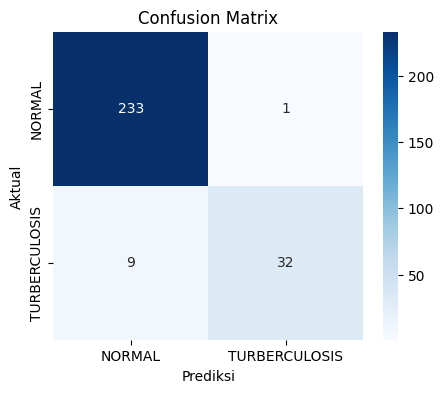

In [16]:
# ------------------------------
# 6. Visualisasi Confusion Matrix
# ------------------------------
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(actual_labels, predicted_classes),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

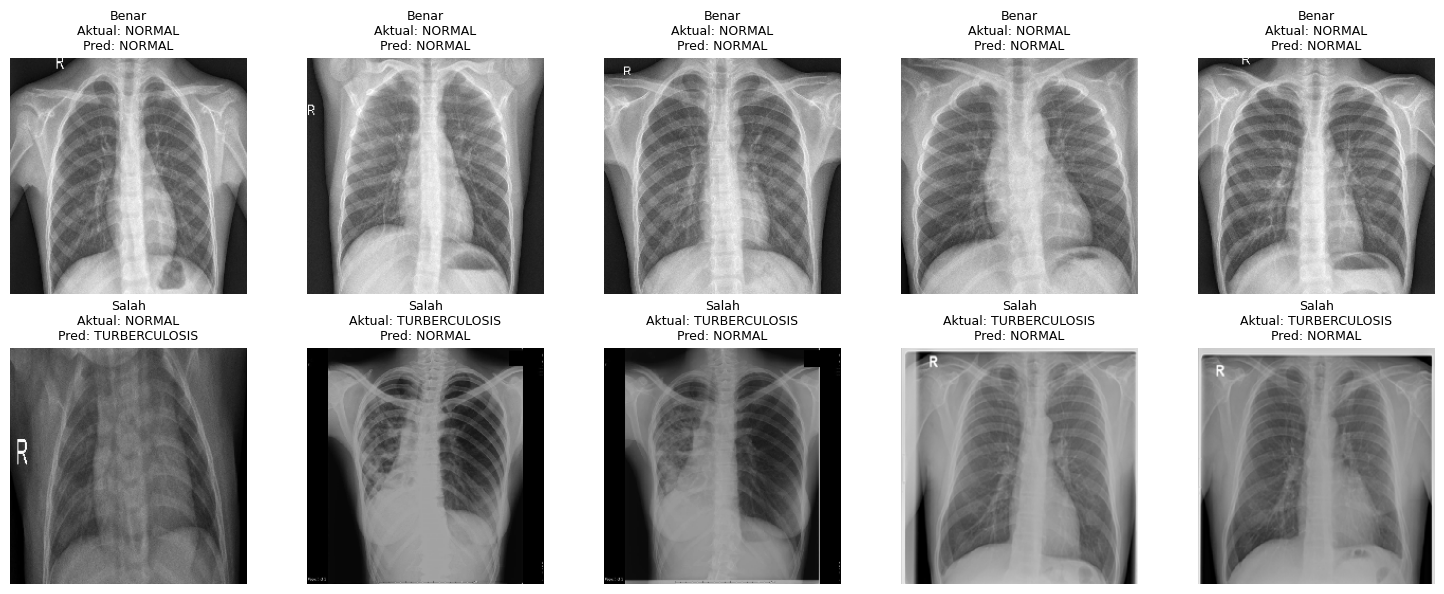


Selesai.


In [17]:
# ------------------------------
# 7. Tampilkan Contoh Gambar: Benar vs Salah
# ------------------------------
correct_indices = np.where(actual_labels == predicted_classes)[0]
wrong_indices   = np.where(actual_labels != predicted_classes)[0]

# Ambil sejumlah sampel (maksimal 5 masing-masing)
n_correct = min(5, len(correct_indices))
n_wrong   = min(5, len(wrong_indices))

def load_and_preprocess_image(index):
    """Muat gambar dari filepath, resize, dan preprocessing."""
    filepath = test_generator.filepaths[index]
    img = load_img(filepath, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)  # sesuai training
    return img_array

# Untuk menampilkan, kita buat grid dengan 2 baris (correct / wrong)
if n_correct == 0 and n_wrong == 0:
    print("Tidak ada gambar untuk ditampilkan.")
else:
    # Tentukan jumlah kolom = maksimal antara n_correct dan n_wrong
    cols = max(n_correct, n_wrong)
    fig, axes = plt.subplots(2, cols, figsize=(3*cols, 6))
    
    # Jika hanya ada 1 baris (misal tidak ada wrong), axes menjadi 1D, kita perlakukan khusus
    if n_correct == 0 or n_wrong == 0:
        axes = np.array([axes]) if n_correct == 0 else axes.reshape(1, -1)
    
    # Tampilkan gambar benar (baris pertama)
    for i in range(cols):
        if i < n_correct:
            idx = correct_indices[i]
            img_array = load_and_preprocess_image(idx)
            # Kembalikan ke rentang 0-1 untuk ditampilkan (karena preprocessing mobilenetv2)
            img_display = img_array / 2 + 0.5
            img_display = np.clip(img_display, 0, 1)
            axes[0, i].imshow(img_display)
            true_label = class_names[actual_labels[idx]]
            pred_label = class_names[predicted_classes[idx]]
            axes[0, i].set_title(f'Benar\nAktual: {true_label}\nPred: {pred_label}', fontsize=9)
        else:
            axes[0, i].axis('off')
        axes[0, i].axis('off')
    
    # Tampilkan gambar salah (baris kedua)
    for i in range(cols):
        if i < n_wrong:
            idx = wrong_indices[i]
            img_array = load_and_preprocess_image(idx)
            img_display = img_array / 2 + 0.5
            img_display = np.clip(img_display, 0, 1)
            axes[1, i].imshow(img_display)
            true_label = class_names[actual_labels[idx]]
            pred_label = class_names[predicted_classes[idx]]
            axes[1, i].set_title(f'Salah\nAktual: {true_label}\nPred: {pred_label}', fontsize=9)
        else:
            axes[1, i].axis('off')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

print("\nSelesai.")